# Assignment 1
Name: Aoi Ueno  

Problem: For this assignment, we focus on data exploration and feature engineering for the following machine learning problem: 
Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)

## 1. Identifying the Prediction Target

- Inspect the dataset and identify which column should be treated as the target variable for this assignment.
- Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.
- Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective.

- Inspect the dataset and identify which column should be treated as the target variable for this assignment.

ANSWER:

I selected y as the target variable because it directly represents the objective of the marketing campaign. "Does a client subscribes to a term deposit?"

The purpose of the campaign is to predict if a contacted client will subscribe or not. The variable y captures this outcome with two possible values, "yes" or "no".The target variable must reflect the real-world outcome that the organization wants to predict. In this case, y directly represents that outcome.

WHY NOT OTHER COLUMNS?:
1. poutcome : This shows the outcome of a previous marketing campaign. It can influence the current decision a bit, but it is not exactly the result I am trying to predict.

2.campaign: This variable shows how many contacts were made during the campaign. It does not represent the final outcome of the campaign = subscription. It is just a  part of the process, not the result i am looking for.

## 2. data loading and exploration

Before applying any splitting, I first need to explore the dataset.
According to lecture 2, data inspection must be done before modeling. 

Aim to understand:
Data types (numerical vs categorical variables)
The structure of the dataset
Missing values

At this stage, I only observe the data. No transformations are applied yet.

In [1]:
import sys
print(sys.version) 

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]


I printed the Python version at the beginning to document the execution environment.  
Earlier, I encountered version related issues, so confirming the Python version helped me check whether failures were caused by the environment rather than my code.  I also used AI assistance here as a debugging aid to quickly identify likely causes and to apply appropriate fix.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("bank-additional.csv")
df.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"30;""blue-collar"";""married"";""basic.9y"";""no"";""ye..."
1,"39;""services"";""single"";""high.school"";""no"";""no""..."
2,"25;""services"";""married"";""high.school"";""no"";""ye..."
3,"38;""services"";""married"";""basic.9y"";""no"";""unkno..."
4,"47;""admin."";""married"";""university.degree"";""no""..."


did not work because of comma

In [4]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.
Identify which variables are numerical and which are categorical.

In [5]:
df.shape

(4119, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

#### Observation

The dataset contains 4,119 observations and 21 columns.

- There are no explicit missing values (NaN) in the dataset.
- The dataset contains numerical (int64, float64) and categorical variables.

- Categorical: job, martal, education, default, housing, loan, contract, month, day_od_week,poutcome, y
- Numerical: age, duration, campaign, pdays, precious, emp.var.rate, cons.price.idx, euribor3m, nr.employed

This means:
- Encoding categorical variables before modeling,so taht i can use for logistic regression
- Careful handling of skewed numerical variables because it will change scailing effect and maybe i need log transformation depending on the case
- Check on implicit missing value is important

At this stage, I only observe the structure of the data. 

In [8]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

The target variable y is highly imbalanced.
The majority class is "no", 3668/4119.

This imbalance may affect model evaluation. Accuracy alone may not be sufficient,
and precision/recall metrics may be more informative.

#### missing value

In [9]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Observation: no missing (explicit) found

In [10]:
for col in df.columns:
    if df[col].astype(str).str.contains("unknown").any():
        print(f"{col} contains implicit missing value, 'unknown'")

job contains implicit missing value, 'unknown'
marital contains implicit missing value, 'unknown'
education contains implicit missing value, 'unknown'
default contains implicit missing value, 'unknown'
housing contains implicit missing value, 'unknown'
loan contains implicit missing value, 'unknown'


Implicit Missing Values

Several categorical variables(job, martial, educatoon, default, housing, loan) contain the value unknown.
This may represent missing or unrecorded information.
These values will need careful handling during preprocessing.

#### visualize distribution at least 2 numerical + categorical variables

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical

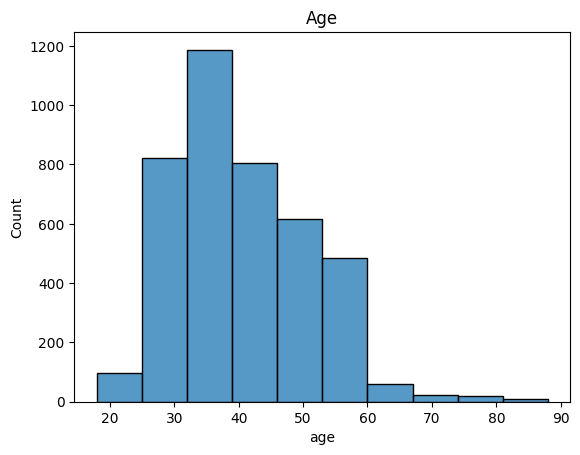

In [12]:
sns.histplot(df["age"], bins=10)
plt.title("Age")
plt.show()

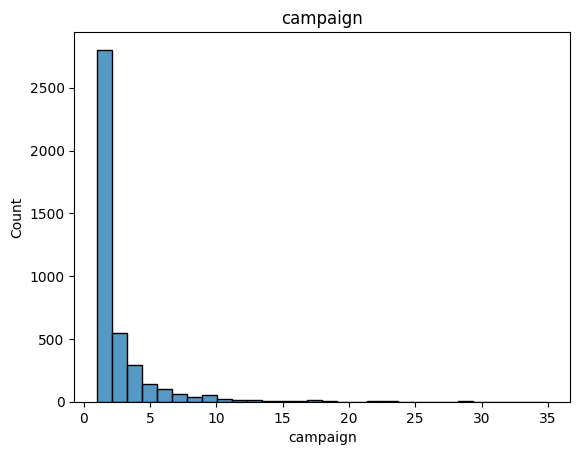

In [13]:
sns.histplot(df["campaign"], bins=30)
plt.title("campaign")
plt.show()

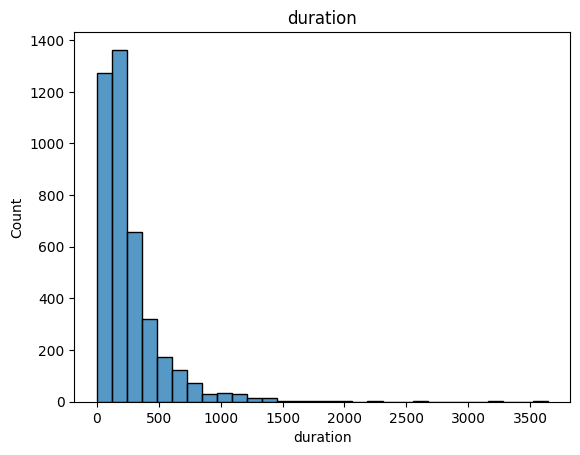

In [14]:
sns.histplot(df["duration"], bins=30)
plt.title("duration")
plt.show()

categorical

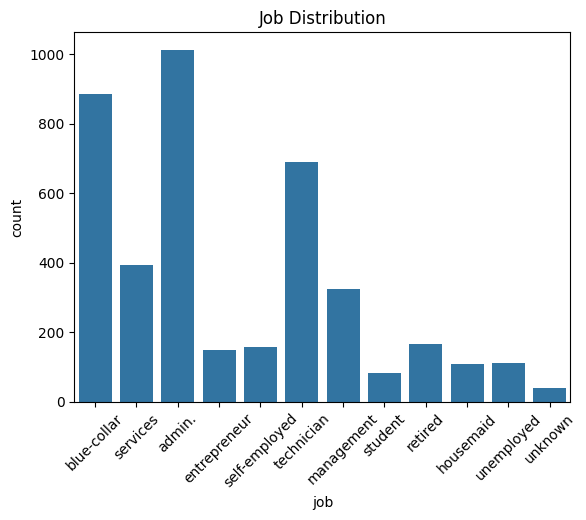

In [15]:
plt.figure()
sns.countplot(data=df, x="job")
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

order them

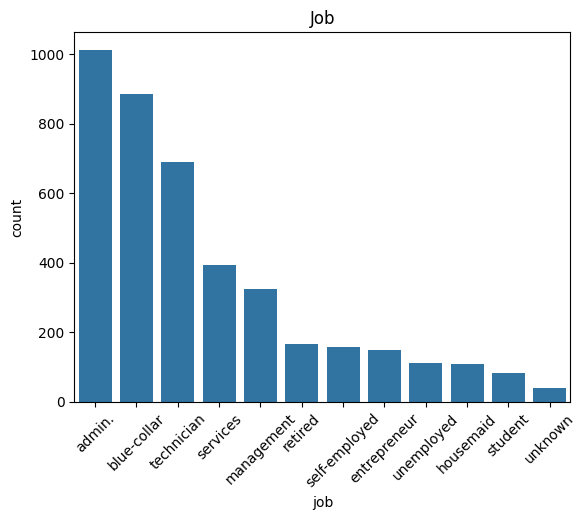

In [16]:
plt.figure()
sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Job")
plt.show()

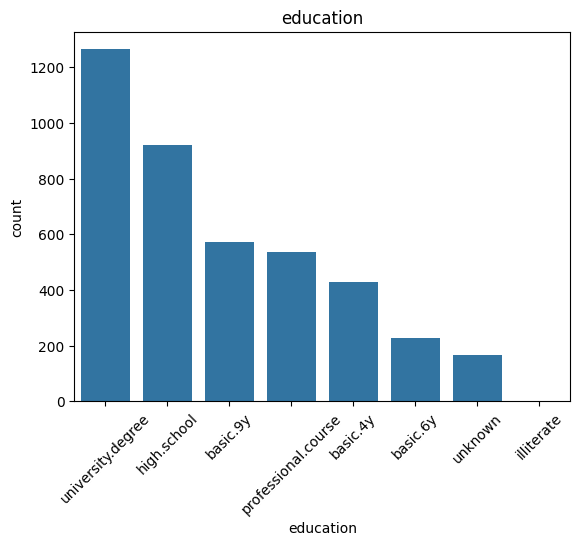

In [17]:
plt.figure()
sns.countplot(data=df, x="education", order=df["education"].value_counts().index)
plt.title("education")
plt.xticks(rotation=45)
plt.show()

Identify at least one variable that may require special consideration before modeling (e.g., due to distributional properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.

ANSWER: duration (numerical variable)

Readon1: it represents the length of the phone call, which is only known after the call ends. 
If the prediction is made at the time of contact, using this variable would introduce data leakage.
To review: 
(Data leackage: when information from outside your training data leaks into your machine learning model while it’s being built.)
Reason2: distribution above is extremely right skewed. This might affect model behavior, and it might need a transformation.

Therefore, to ensure a realistic prediction setting and avoid leakage, I remove duration from the feature set before training the model.
(deleting below)

## 3. Data Splitting

Split the dataset into training, validation, and test sets.
• Justify your choice of proportions for each split.
• Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.
• Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage
would arise if splitting were performed later.

WHY data splitting now?

If I perform preprocessing before splitting, information from the validation or test set may leak into the training process.
Data splitting must occur before any preprocessing steps that learn parameters from the data. If splitting were performed after these transformations, information from the validation or test sets would be incorporated into the training process. This would result in data leakage.

For example:
- If imputation is performed before splitting, the overall dataset mean would be used to fill missing values.
- If scaling is done before splitting, the mean and standard deviation would be calculated using the entire dataset.
- If feature selection is applied before splitting, features would be chosen based on patterns from all data, including the test set.
- If resampling is done before splitting, synthetic samples could appear in the validation or test sets.

In all of these cases, information from the test data would influence the training process, leading to data leakage.
Such leakage would lead to overly optimistic results and reduce the reliability of model performance.

Therefore, data splitting is performed  at this stage.

Split the dataset into training, validation, and test sets.
Justify your choice of proportions for each split.
Perform stratified splitting with respect to the target variable and explain why stratification is necessary for
this dataset.


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df.drop("y", axis=1)
y = df["y"]

In [20]:
X = X.drop(columns=["duration"])
#deleting duration (as i observe from data exploration)

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [22]:

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

Note on AI Use  
I was not sure what value to use for `random_state`, so with the help of AI, I decided to use 42.  
The specific number itself is not important, but setting a `random_state` ensures reproducibility, meaning the results can be replicated consistently. The value 42 is commonly used as a conventional example in programming and machine learning.

Justification of the Data Split Proportion

The dataset was split into 70% training, 15% validation, and 15% test sets.

First, 70% of the data to the training set ensures that the model has enough data to learn patterns.

Second, separate validation and test sets are necessary to avoid data leakage. The validation set is used for model tuning and selection, and the test set is for final unbiased evaluation.

Finally, since the dataset is imbalanced (target variable y is 3668/451), allocating 15% to both validation and test sets ensures that each subset contains enough minority class examples for reliable evaluation.

## 4. Missing value handling
Identify both explicit missing values (e.g., NaN) and implicit missing values (e.g., categories such as unknown
or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements).
- Quantify the extent of missingness for each affected variable.
- Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate
category, indicator variable).
- Clearly state which operations must be fitted using the training set only, and explain why.

Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries)
and “modeling” decisions (e.g., whether missingness itself may carry predictive information).

First, check explicit missing value(NaN)

In [23]:
X_train.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

Next, check imexlicit missing value(such as unknown)

In [24]:
for col in X_train.columns:
    count_unknown = (X_train[col] == "unknown").sum()
    if count_unknown > 0:
        print(f" variable: ({col}) {count_unknown} unknown values")

 variable: (job) 25 unknown values
 variable: (marital) 7 unknown values
 variable: (education) 112 unknown values
 variable: (default) 577 unknown values
 variable: (housing) 65 unknown values
 variable: (loan) 65 unknown values


#### Missing Value Strategy

There are no explicit missing values (NaN) in the dataset. However, several categorical variables contain the value "unknown", 
which might represent unrecorded information.

I distinguish between data cleaning decisions and modeling decisions.

From a data cleaning perspective, there are no corrupted entries that require correction. So i do not need to remoce any rows.

From a modeling perspective, the inexplicit missing value unknown may carry predictive information, so instead of removing these observations or imputing them, I treat "unknown" as a separate category. 
This avoids information loss and allows the model to learn whether missingness itself is informative.

If numerical missing values were present, I would apply median imputation, fitted on the training set only. 
In Lecture 5, it says that imputation estimates statistical parameters from data, and therefore must not use validation or test data to avoid data leakage.

All preprocessing steps that learn parameters are fitted using the training set only and then applied to validation and test sets.

## 5. Encoding categorical variables: Identify all categorical variables in the dataset.
- Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables
(categories with a meaningful order, e.g., education level), and justify your classification.
- Select and apply an appropriate encoding strategy for each categorical variable.
- Clearly state which encoders must be fitted on the training set only, and explain why.
  
- Analyze how encoding changes:
– the dimensionality of the dataset;
– the interpretability of model coefficients;
– the types of decision boundaries a linear model can represent.

#### Identification of Categorical Variables
Variables below are categorical:
job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome.

Nominal vs Ordinal Variables
- Most categorical variables in this dataset are nominal, meaning they do not have an intrinsic order (e.g., job type, marital status, contact type).
- The variable `education` could be considered ordinal since education levels follow a natural progression. However, the exact numeric distance between these categories is unclear. 
Therefore, all categorical variables are treated as nominal.

Encoding Strategy: One-Hot Encoding to all categorical variables.
- It's appropriate for nominal variables.
- Does not impose artificial ordering on categories.
- Expands the feature space, allowing the linear model to capture category specific effects.
- Although education has an order, I apply one-hot encoding to avoid imposing a linear distance assumption between education levels.
- This allows the model to learn category-specific effects without assuming equal spacing between levels.

The encoder is fitted using only the training data and then applied to validation and test sets. 
This prevents data leakage, since encoding learns category mappings from the data.

In [25]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

/var/folders/yr/kg6lw55s2jgdrr2__8l6grc80000gn/T/ipykernel_59001/2654008446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [26]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=["str"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

In [27]:
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [28]:
numerical_cols

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [29]:
# Step 2: Initialize encoder (version-safe)
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

#### Note on AI Use on above block

During implementation, a version-related error occurred due to differences in the OneHotEncoder arguments across scikit-learn versions. 
I use AI assistance to quickly identify the cause of the error and adapt the code accordingly. 

In [30]:
encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [31]:
X_train_cat = encoder.transform(X_train[categorical_cols])
X_val_cat   = encoder.transform(X_val[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

combine with numerical variabels 

In [32]:
X_train_final = np.concatenate(
    [X_train[numerical_cols].values, X_train_cat],
    axis=1
)

X_val_final = np.concatenate(
    [X_val[numerical_cols].values, X_val_cat],
    axis=1
)

X_test_final = np.concatenate(
    [X_test[numerical_cols].values, X_test_cat],
    axis=1
)

In [33]:
print(X_train_final.shape)

(2883, 62)


In [34]:
print("Trai:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

Trai: (2883, 62)
Validation: (618, 62)
Test: (618, 62)


#### Impact on Dimensionality
One-Hot Encoding increases the number of features in the dataset.  Since each category is converted into its own binary column, the total number of variables grows.  This expands the feature space and makes the dataset higher-dimensional.

#### Impact on Interpretability
In Logistic Regression, each encoded category has its own coefficient.  This makes it easier to understand how a specific category (for example, a certain job type) influences the probability of subscription compared to a reference category. Therefore, One-Hot Encoding helps maintain interpretability of the model.

#### Impact on Decision Boundaries
Logistic Regression is a linear model, meaning it learns a linear decision boundary in the feature space.  By expanding the feature space through One-Hot Encoding, the model becomes more flexible.  Although the boundary is still linear in the transformed space, it can represent different effects for different categories, which would not be possible without encoding.

## 6. Feature scaling.
 Identify the numerical variables that require scaling.
• Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.
• Justify your choice of scaling method in the context of Logistic Regression.
• Clearly state which transformations must be fitted on the training set only, and explain why.
• Discuss how feature scaling affects:
– gradient-based optimization;
– the magnitude and comparability of model coefficients;
– the interpretation of regularization penalties.

Note: Feature scaling is not a cosmetic transformation. Your justification should explicitly connect your scaling
decision to the mathematical behavior of linear models.

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [37]:
X_train_num_scaled = scaler.transform(X_train[numerical_cols])
X_val_num_scaled   = scaler.transform(X_val[numerical_cols])
X_test_num_scaled  = scaler.transform(X_test[numerical_cols])

In [38]:
X_train_final = np.concatenate([X_train_num_scaled, X_train_cat], axis=1)
X_val_final   = np.concatenate([X_val_num_scaled,   X_val_cat],   axis=1)
X_test_final  = np.concatenate([X_test_num_scaled,  X_test_cat],  axis=1)

In [39]:
print("Train", X_train_final.shape)
print("Validation", X_val_final.shape)
print("Test", X_test_final.shape)

Train (2883, 62)
Validation (618, 62)
Test (618, 62)


### Feature Scaling justtification

Feature scaling is applied to the numerical variables so that they are on a comparable scale.

Logistic Regression uses gradient-based optimization, which means that features with larger numerical ranges can have a stronger influence during training. If one variable has much larger values than others, it may dominate the learning process.

To address this, I use StandardScaler to standardize the numerical features. This transformation rescales each variable to have a mean of 0 and a standard deviation of 1.

The scaler is fitted using only the training data and then applied to the validation and test sets. This ensures that no information from unseen data influences the scaling process, preventing data leakage.

The one-hot encoded categorical variables are not scaled, since they are already binary (0/1) and operate on a consistent scale..

## 7. Feature selection
• Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.
• Identify highly correlated numerical features and decide whether any should be removed. Clearly state the
threshold used and justify your decision.
• Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy,
availability at prediction time, or risk of data leakage).
• Explain why feature selection must be performed using the training set only.
• Discuss the consequences of performing feature selection on the entire dataset before splitting.
Note: Feature selection is not purely statistical. Your reasoning should explicitly connect your decisions to the
assumptions and stability of Logistic Regression.

In [40]:
#check low variance here
variances = np.var(X_train_final, axis=0)

low_variance_features = np.where(variances < 1e-5)[0]
len(low_variance_features)

0

In [41]:
X_train_num_df = pd.DataFrame(
    X_train_final[:, :len(numerical_cols)],
    columns=numerical_cols
)

corr_matrix = X_train_num_df.corr().abs()

threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j])
            )

high_corr_pairs

[('euribor3m', 'emp.var.rate'), ('nr.employed', 'euribor3m')]

### Handling Highly Correlated Features

Correlation analysis identified strong correlations between:

- euribor3m and emp.var.rate  
- euribor3m and nr.employed  

Since highly correlated features introduce multicollinearity, which can destabilize coefficient estimates in Logistic Regression, I removed redundant macroeconomic variables.

We retained euribor3m as a representative economic indicator and removed emp.var.rate and nr.employed to reduce redundancy.

This decision improves model stability and interpretability.

In [42]:
num_cols = numerical_cols.copy()

#remove variables here
remove_features = ['emp.var.rate', 'nr.employed']

remove_indices = [num_cols.index(f) for f in remove_features]

#remove from final matrices
X_train_final = np.delete(X_train_final, remove_indices, axis=1)
X_val_final   = np.delete(X_val_final, remove_indices, axis=1)
X_test_final  = np.delete(X_test_final, remove_indices, axis=1)

print("New shape", X_train_final.shape)

New shape (2883, 60)


## 8. Addressing class imbalance
Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this
prediction task.
• Propose and apply a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify
at which stage of the pipeline the resampling step should occur.
• Justify your choice of resampling method in terms of its assumptions and expected effect on the learning
algorithm.
• Explain what would happen if resampling were applied before splitting the dataset into training, validation,
and test sets. Discuss the implications for model evaluation.
• Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

Note: Resampling is part of the training procedure and must be applied to the training set only. Validation and
test sets must preserve the original class distribution.

#### Addressing Class Imbalance

Class Distribution
The training set is clearly imbalanced, with about 11% positive and 89% negative cases.  
This imbalance is concerning because the model may learn to predict the majority class most of the time. This leads oerall accuracy could look high, while the model performs poorly in identifying the minority class.

Resampling Strategy
To address, I apply SMOTEto the training set only. This helps balance the dataset without simply duplicating observations.
Resampling is performed after feature selection and scaling, but before training the model.

Why: SMOTE is preferred over simple random oversampling because it introduces new synthetic variations rather than exact copies of minority samples. This reduces the risk of overfitting!
A more balanced training set allows Logistic Regression to learn a more appropriate decision boundary, instead of being biased toward the majority class.

Why Training Set Only?: Resampling must be applied only to the training set.
If SMOTE were applied before splitting the data, synthetic samples could be influenced by validation. This would introduce data leakage and lead to overly optimistic evaluation results.
To ensure fair and realistic valuation, the validation and test sets must preserve the original class distribution.

#### Impact on Evaluation Metrics
In imbalanced datasets, accuracy can be misleading. A model that always predicts the majority class could still achieve high accuracy.
Therefore, metrics such as precision and recall are more informative:
- Precision measures how many predicted positive cases are actually correct.
- Recall measures how many actual positive cases are successfully identified.
By balancing the training data, the model is better able to detect minority cases, which typically improves recall while maintaining reasonable precision.

In [43]:
from imblearn.over_sampling import SMOTE

In [44]:
smote = SMOTE(random_state=42)

In [45]:
#apply on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_final, 
    y_train
)

In [46]:
#compare before and after
print(y_train.value_counts())

print(y_train_resampled.value_counts())

y
no     2567
yes     316
Name: count, dtype: int64
y
no     2567
yes    2567
Name: count, dtype: int64


## 9. Logistic regression
 Train a Logistic Regression model to predict whether a client subscribes to a term deposit.
• Use the validation set to generate predictions.
• Report at least Accuracy, Precision, and Recall on the validation set.
• Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result.

Note: The goal here is not to squeeze out the best possible performance. The goal is to verify that your data
preparation pipeline is coherent and correctly implemented. If your preprocessing is principled, the model should
behave sensibly. If it behaves strangely, that is a signal to revisit earlier decisions. Have fun finding a visually
appealing way to display the predictions or the confusion matrix on the validation set. This is your chance to make
the output readable and professional 8-)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [48]:
model = LogisticRegression(solver="lbfgs", max_iter=2000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Logistic Regression with L2 regularization and the "lbfgs" solver is used, as it provides stable and efficient optimization.
The number of iterations is increased to ensure convergence. A fixed random state is set for reproducibility.

In [49]:
y_val_predicted = model.predict(X_val_final)

In [50]:
y_val_predicted

array(['no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no',
       'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no',
       'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no',
       'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'yes', 'yes', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no',
       'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no',
       'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'yes', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'yes',
       'no', 'no', 'no', 'no', 'no', 'no', 'y

In [51]:
accuracy = accuracy_score(y_val, y_val_predicted)
precision = precision_score(y_val, y_val_predicted, pos_label="yes")
recall = recall_score(y_val, y_val_predicted, pos_label="yes")


In [52]:
print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")

Accuracy : 0.7944983818770227
Precision: 0.29931972789115646
Recall   : 0.6470588235294118


Compare accuracy with zero base line

In [53]:
major_class = y_train.value_counts().idxmax()
y_val_zero = [major_class] * len(y_val)
zero_accuracy = accuracy_score(y_val, y_val_zero)

In [54]:
print(f"Zero Rule Accuracy{zero_accuracy}")
print(f"Model Accuracy {accuracy}")

Zero Rule Accuracy0.889967637540453
Model Accuracy 0.7944983818770227


The Zero Rule baseline is approximately 0.89 by always predicting the majority class ("no").
The Logistic Regression model achieves a validation accuracy of approximately 0.79, which is slightly lower than the baseline.

Although overall accuracy does not improve, this result is expected under class imbalance. 
The model substantially increases recall for the minority class (≈0.76), meaning it correctly identifies a large proportion of actual subscribers.

This comparison shows that accuracy alone is not sufficient in imbalanced settings, and recall provides a more meaningful measure of model performance.

## 10. Task ordering
Why Task Ordering Is Presented at the End?

I chose task ordering presented at the end because it serves as a synthesis of the entire workflow. 
Only after completing all preprocessing, and modeling steps, i can clearly justify the correct sequence.
That is why dentifying the prediction target must be performed first, since all subsequent decisions depend on clearly defining the modeling objective.
Therefore, Task Ordering functions as a structured reflection on the full modeling pipeline rather than an independent preprocessing step.

#### Instruction
Determine the correct order in which the data preparation tasks in this assignment should be performed.
• Provide a structured justification for your chosen order.
• For each step in your proposed sequence, explain:
– what information is allowed to be used at that stage;
– what information must not be used;
– what type of data leakage could occur if the order were changed.
• Discuss at least one example of an incorrect ordering and explain the consequences it would have on model
evaluation.

#### Correct Order of Data Preparation Steps as a Final Summary
1. Identify the prediction target  
2. Data loading and exploration  
3. Data splitting(train / validation /test)  
4. Handling missing values  
5. Encoding categorical variables  
6. Feature scaling  
7. Feature selection  
8. Addressing class imbalance
9. Train logistic regression model
10. Task ordering

Data splitting must be done before any transformation that learns from the data. Once the dataset is divided into training, validation, and test sets, all preprocessing steps should be fitted using the training set only.

Several steps in the pipeline estimate parameters from the data, including:
- Missing value imputation (which calculates summary statistics such as the mean or median)
- Encoding (which learns the set of categories)
- Scaling (which computes the mean and standard deviation)
- Feature selection (which identifies relationships between variables)
- Resampling (which generates synthetic samples)

Because these steps rely on information extracted from the data, they must only use the training set. The validation and test sets must remain untouched to ensure that model evaluation reflects true generalization performance.

#### Information Usage at Each Stage
- Before splitting: Only descriptive exploration is allowed. No transformations that compute statistics.
- After splitting: Preprocessing steps may use training data statistics.
- Validation/Test: Only transformation using parameters learned from training data is allowed. No fitting.

#### If i order steps incorresctly, what would happen?
For example:
- Apply SMOTE before splitting into train/validation/test. -> SMOTE creates synthetic minority samples using information from the full dataset. After the split, very similar (or related) synthetic patterns can end up in both the training and validation/test sets.
-> The validation/test performance becomes high because the model is indirectly evaluated on data that is not truly independent from what it trained on. This is a data leakage.
- Perform feature selection using the full dataset before splitting. -> The decision of which features to keep is influenced by relationships that exist in the validation/test sets.
-> The selected feature set is partially tuned to the evaluation data, which biases performance upward. The model appears more stable/accurate than it would be on truly unseen data.